# Four-body amplitude analysis: toy closure

This example uses both `P -> (ab)(cd)` and `P -> R a -> (S b) a -> ((cd)b)a`, with scalar external particles. It fits an independent continuous toy with the existing `FitSession` and a fixed weighted MC normalization sample. See [the conventions and architecture audit](../../docs/four_body.md).

The reference coefficient is fixed to remove the unobservable global scale and phase. A single toy is a closure smoke test, not a coverage study.


In [1]:
from pathlib import Path
import sys

root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "examples/four_body_closure.py").exists())
sys.path.insert(0, str(root))
from examples.four_body_closure import run_closure


## Generate and fit

The toy sampler uses an analytical rejection bound for this specific scalar fixed-width-pole model. Its events and the normalization sample use independent seeds. No finite candidate pool is recycled. The normalization uses `mean(weights * intensity)`, and is fixed throughout the fit.


In [2]:
session, result, summary = run_closure(events=6000, normalization=200_000)
summary


{
  "valid": true,
  "events": 6000,
  "normalization": 200000,
  "proposals": 320000,
  "truth": {
    "cascade.x": 0.55,
    "cascade.y": 0.35
  },
  "fitted": {
    "cascade.x": 0.5479225975210604,
    "cascade.y": 0.3594250887703738
  },
  "errors": {
    "cascade.x": 0.025594110087409194,
    "cascade.y": 0.024955231117308657
  },
  "pulls": {
    "cascade.x": -0.08116720885566468,
    "cascade.y": 0.37767988307015576
  },
  "elapsed_seconds": 19.63136508502066
}


{'valid': True,
 'events': 6000,
 'normalization': 200000,
 'proposals': 320000,
 'truth': {'cascade.x': 0.55, 'cascade.y': 0.35},
 'fitted': {'cascade.x': 0.5479225975210604, 'cascade.y': 0.3594250887703738},
 'errors': {'cascade.x': 0.025594110087409194,
  'cascade.y': 0.024955231117308657},
 'pulls': {'cascade.x': -0.08116720885566468,
  'cascade.y': 0.37767988307015576},
 'elapsed_seconds': 19.63136508502066}

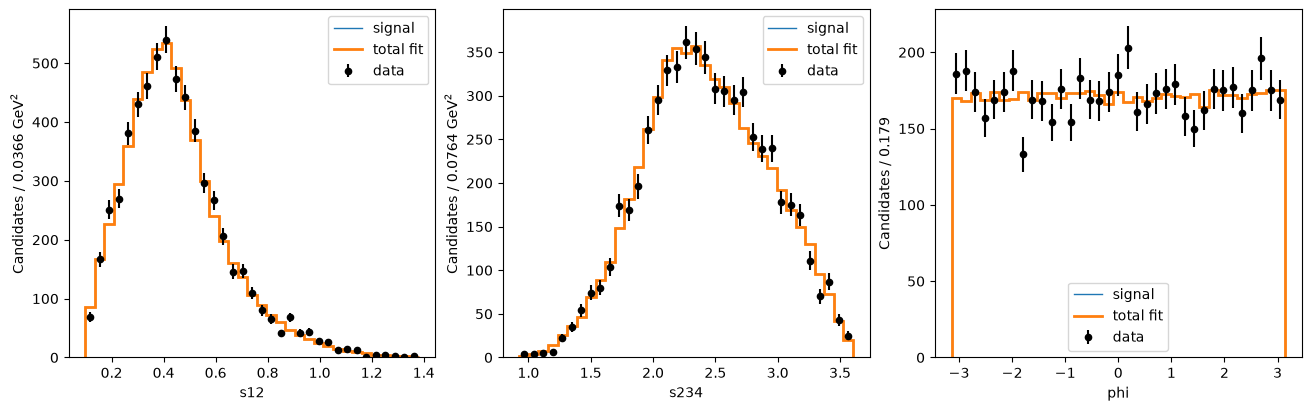

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, observable in zip(axes, ("s12", "s234", "phi")):
    session.plot_projection(result, observable, bins=35,
                            projection_sample=session.model.normalization_sample, ax=ax)
    ax.set_xlabel(observable)
plt.show()


## Coordinates and nonzero intermediate spin

There are five internal coordinates for a scalar parent. The four-vectors are covariant storage; subset masses, helicity cosines and the signed azimuth are invariant under proper Lorentz transformations. The signed angle preserves the orientation information discarded by pair masses alone.

The next cell demonstrates an LS=0 pair of vector isobars and a cascade with `J_R=J_S=1, L_R=0`. They are additional waves, not part of the scalar closure above. The pair uses the existing running-width Breit-Wigner for stable daughter pairs. The outer cascade uses the default fixed-width `Pole`: a two-stable-body running width is not a valid general width for an unstable daughter.


In [4]:
import jax
import jax.numpy as jnp
from jaxpwa import (Isobar, PairChain, CascadeChain, RelativisticBreitWigner,
                    pair_coordinates, cascade_coordinates, pair_coordinates_to_momenta)

sample = session.model.normalization_sample.take(jnp.arange(128))
pair = PairChain(Isobar(.65, .3, spin=1, lineshape=RelativisticBreitWigner()),
                 Isobar(.95, .35, spin=1, lineshape=RelativisticBreitWigner()), orbital=0)
cascade = CascadeChain(Isobar(1.45, .35, spin=1), Isobar(.95, .35, spin=1), orbital=0)
assert jnp.all(jnp.isfinite(jax.jit(pair)(sample.as_dict())))
assert jnp.all(jnp.isfinite(jax.jit(cascade)(sample.as_dict())))
angles = pair_coordinates(sample.momenta)
{k: v[:3] for k, v in angles.items()}


{'s_ab': Array([0.52050428, 0.49718128, 0.12535333], dtype=float64),
 's_cd': Array([1.01759361, 1.49963026, 1.92742286], dtype=float64),
 'cos_theta1': Array([-0.91134431,  0.18753677,  0.46391284], dtype=float64),
 'cos_theta2': Array([-0.70673605,  0.56696948, -0.95694036], dtype=float64),
 'phi': Array([ 0.2179282 , -1.18480257, -2.98770716], dtype=float64)}

In [5]:
canonical = pair_coordinates_to_momenta(2., (.1,.2,.3,.4),
    angles["s_ab"], angles["s_cd"], angles["cos_theta1"], angles["cos_theta2"], angles["phi"])
import numpy as np
np.testing.assert_allclose(jnp.exp(1j*pair_coordinates(canonical)["phi"]),
                           jnp.exp(1j*angles["phi"]), atol=1e-12)


## Floating dynamics and further validation

Use `Parameter.dynamics("mass", value, owner="component_name")` for a pole mass/width/radius that should float. The prepared cache retains fixed angular geometry and updates the affected component and normalization matrix during fitting.

Before a physics analysis, vary the normalization size and seed, model narrow resonances with adequate integration statistics, choose waves consistent with parity at strong vertices, and run a multi-toy pull study. External spin, general three-body running widths, and Dalitz-specific ROOT/CP/SCF convenience APIs are outside this initial implementation.
